# EDA — International Match Results
**Sources**: Mart Jürisoo (`results.csv`, `goalscorers.csv`, `shootouts.csv`) + PataterieData (`all_matches.csv`)

**Purpose**: Profile the primary training data for the Dixon-Coles Poisson model. Check coverage, freshness, goal distributions, tournament mix, and neutral-venue flags.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
DATA = Path('../data/raw/mart_jurisoo')

## 1. Load & Basic Profile

In [2]:
results = pd.read_csv(DATA / 'results.csv', parse_dates=['date'])
goalscorers = pd.read_csv(DATA / 'goalscorers.csv', parse_dates=['date'])
shootouts = pd.read_csv(DATA / 'shootouts.csv', parse_dates=['date'])
patarie = pd.read_csv(DATA / 'all_matches.csv', parse_dates=['date'])

print('results shape:', results.shape)
print('goalscorers shape:', goalscorers.shape)
print('shootouts shape:', shootouts.shape)
print('patarie shape:', patarie.shape)
results.head(3)

results shape: (49477, 9)
goalscorers shape: (47606, 8)
shootouts shape: (678, 5)
patarie shape: (51647, 8)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False


In [3]:
print('=== results.csv dtypes & missing ===')
missing = results.isnull().mean().mul(100).round(2)
dtypes = results.dtypes
summary = pd.DataFrame({'dtype': dtypes, 'missing_%': missing})
print(summary)
print('\nDate range:', results['date'].min(), '->', results['date'].max())
print('Unique home teams:', results['home_team'].nunique())
print('Unique away teams:', results['away_team'].nunique())
print('Neutral venue %:', results['neutral'].mean()*100, '%')

=== results.csv dtypes & missing ===
                     dtype  missing_%
date        datetime64[us]       0.00
home_team              str       0.00
away_team              str       0.00
home_score         float64       0.14
away_score         float64       0.14
tournament             str       0.00
city                   str       0.00
country                str       0.00
neutral               bool       0.00

Date range: 1872-11-30 00:00:00 -> 2026-06-27 00:00:00
Unique home teams: 327
Unique away teams: 321
Neutral venue %: 26.51939284920266 %


## 2. Temporal Coverage

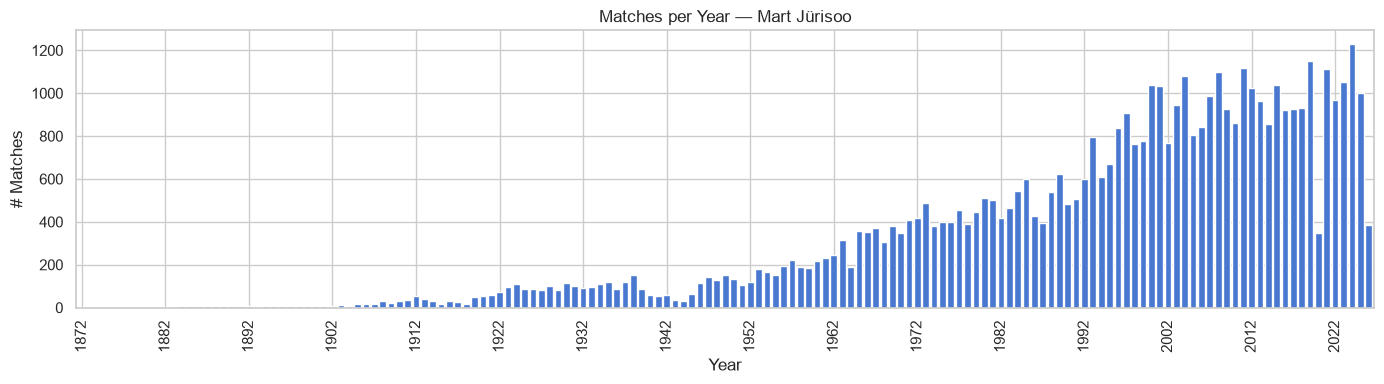

Matches 1990+: 32359
Matches 2015+: 11063
Matches 2024+: 2616


In [4]:
results['year'] = results['date'].dt.year
yearly = results.groupby('year').size()

fig, ax = plt.subplots(figsize=(14, 4))
yearly.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Matches per Year — Mart Jürisoo')
ax.set_xlabel('Year')
ax.set_ylabel('# Matches')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

print('Matches 1990+:', (results['year'] >= 1990).sum())
print('Matches 2015+:', (results['year'] >= 2015).sum())
print('Matches 2024+:', (results['year'] >= 2024).sum())

## 3. Tournament Mix

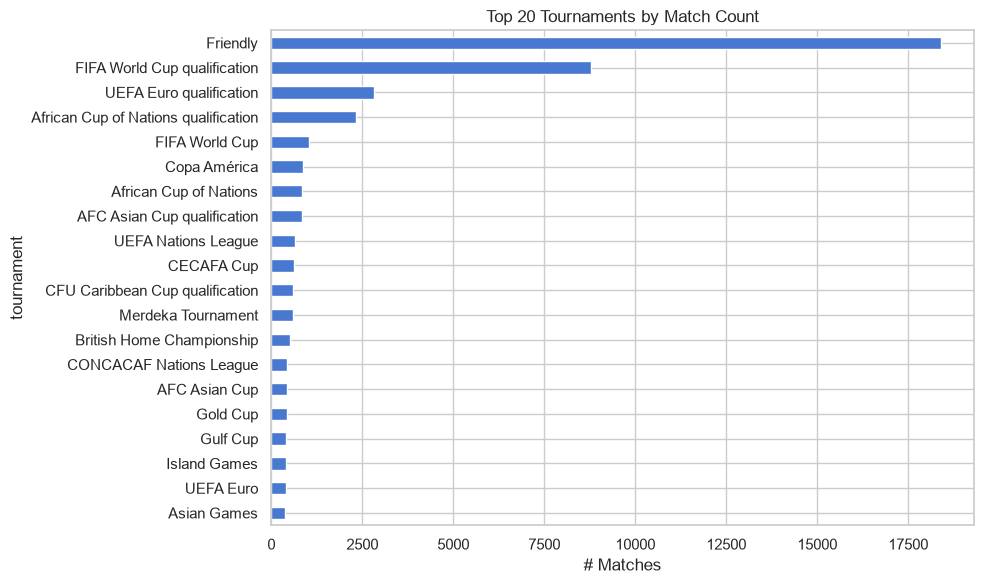

World Cup matches: 9807
Friendly matches: 18388
Non-friendly, non-WC: 21282


In [5]:
top_tournaments = results['tournament'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_tournaments.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 20 Tournaments by Match Count')
ax.set_xlabel('# Matches')
plt.tight_layout()
plt.show()

# World Cup specific
wc_mask = results['tournament'].str.contains('FIFA World Cup', na=False)
print('World Cup matches:', wc_mask.sum())
print('Friendly matches:', (results['tournament'] == 'Friendly').sum())
print('Non-friendly, non-WC:', (~wc_mask & (results['tournament'] != 'Friendly')).sum())

## 4. Goal Score Distributions

Rows with missing scores: 70


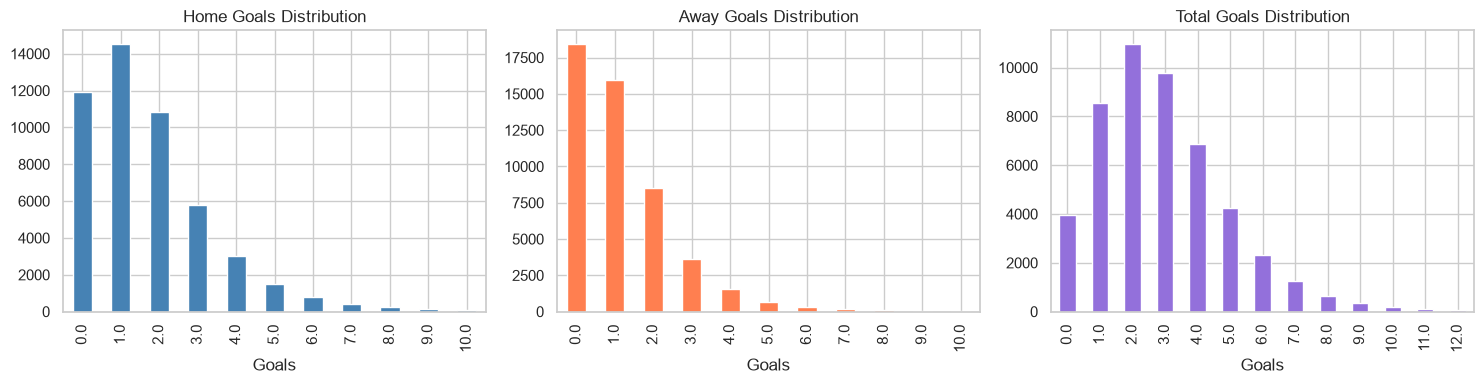

Mean home goals: 1.757
Mean away goals: 1.182
Home win %: 49.0%
Draw %: 22.7%
Away win %: 28.3%


In [6]:
results_clean = results.dropna(subset=['home_score', 'away_score'])
print('Rows with missing scores:', results.shape[0] - results_clean.shape[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Home goals
home_counts = results_clean['home_score'].value_counts().sort_index()
home_counts[home_counts.index <= 10].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Home Goals Distribution')
axes[0].set_xlabel('Goals')

# Away goals
away_counts = results_clean['away_score'].value_counts().sort_index()
away_counts[away_counts.index <= 10].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Away Goals Distribution')
axes[1].set_xlabel('Goals')

# Total goals
results_clean['total_goals'] = results_clean['home_score'] + results_clean['away_score']
total_counts = results_clean['total_goals'].value_counts().sort_index()
total_counts[total_counts.index <= 12].plot(kind='bar', ax=axes[2], color='mediumpurple')
axes[2].set_title('Total Goals Distribution')
axes[2].set_xlabel('Goals')

plt.tight_layout()
plt.show()

print(f'Mean home goals: {results_clean["home_score"].mean():.3f}')
print(f'Mean away goals: {results_clean["away_score"].mean():.3f}')
print(f'Home win %: {(results_clean["home_score"] > results_clean["away_score"]).mean()*100:.1f}%')
print(f'Draw %: {(results_clean["home_score"] == results_clean["away_score"]).mean()*100:.1f}%')
print(f'Away win %: {(results_clean["home_score"] < results_clean["away_score"]).mean()*100:.1f}%')

## 5. Goal Distributions — World Cup Only vs All

In [7]:
wc_results = results_clean[results_clean['tournament'].str.contains('FIFA World Cup', na=False)]
friendly_results = results_clean[results_clean['tournament'] == 'Friendly']

for label, subset in [('World Cup', wc_results), ('Friendly', friendly_results), ('All', results_clean)]:
    print(f'{label}: n={len(subset)}, mean_home={subset["home_score"].mean():.3f}, mean_away={subset["away_score"].mean():.3f}, draw%={(subset["home_score"]==subset["away_score"]).mean()*100:.1f}%')

World Cup: n=9737, mean_home=1.761, mean_away=1.119, draw%=21.2%
Friendly: n=18388, mean_home=1.692, mean_away=1.183, draw%=25.1%
All: n=49407, mean_home=1.757, mean_away=1.182, draw%=22.7%


## 6. Home Advantage: Home vs Neutral Venue

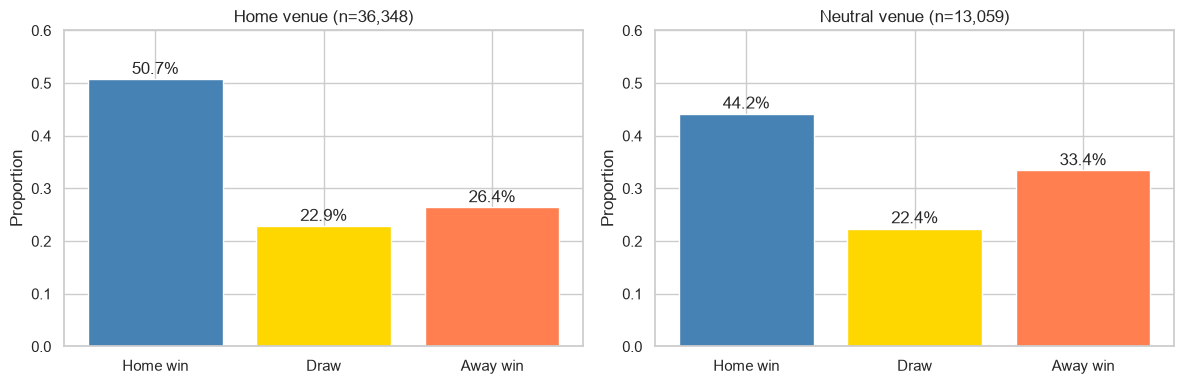

Home venue mean goals: home=1.788, away=1.114
Neutral venue mean goals: home=1.671, away=1.371
Home advantage λ boost: 0.118


In [8]:
home_venue = results_clean[~results_clean['neutral']]
neutral_venue = results_clean[results_clean['neutral']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, subset) in zip(axes, [('Home venue', home_venue), ('Neutral venue', neutral_venue)]):
    categories = ['Home win', 'Draw', 'Away win']
    values = [
        (subset['home_score'] > subset['away_score']).mean(),
        (subset['home_score'] == subset['away_score']).mean(),
        (subset['home_score'] < subset['away_score']).mean(),
    ]
    ax.bar(categories, values, color=['steelblue', 'gold', 'coral'])
    ax.set_title(f'{label} (n={len(subset):,})')
    ax.set_ylim(0, 0.6)
    ax.set_ylabel('Proportion')
    for i, v in enumerate(values):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

print(f'Home venue mean goals: home={home_venue["home_score"].mean():.3f}, away={home_venue["away_score"].mean():.3f}')
print(f'Neutral venue mean goals: home={neutral_venue["home_score"].mean():.3f}, away={neutral_venue["away_score"].mean():.3f}')
print(f'Home advantage λ boost: {home_venue["home_score"].mean() - neutral_venue["home_score"].mean():.3f}')

## 7. Poisson Fit Check

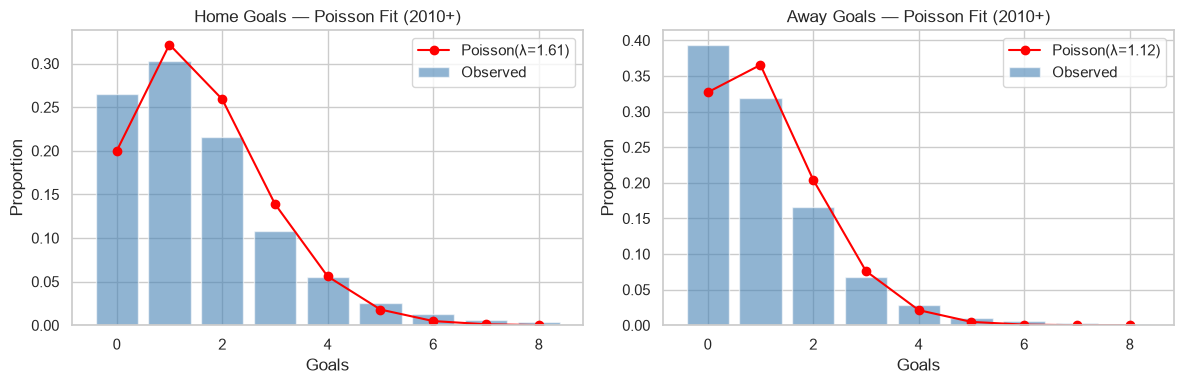

In [9]:
from scipy.stats import poisson

recent = results_clean[results_clean['year'] >= 2010]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in [(axes[0], 'home_score', 'Home Goals'), (axes[1], 'away_score', 'Away Goals')]:
    data = recent[col].astype(int)
    lam = data.mean()
    max_g = min(data.max(), 8)
    observed = data.value_counts(normalize=True).sort_index()
    observed = observed[observed.index <= max_g]
    expected_x = np.arange(0, max_g + 1)
    expected_y = poisson.pmf(expected_x, lam)

    ax.bar(observed.index, observed.values, alpha=0.6, label='Observed', color='steelblue')
    ax.plot(expected_x, expected_y, 'o-', color='red', label=f'Poisson(λ={lam:.2f})')
    ax.set_title(f'{label} — Poisson Fit (2010+)')
    ax.set_xlabel('Goals')
    ax.set_ylabel('Proportion')
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Freshness: PataterieData Supplement Coverage

In [10]:
print('PataterieData columns:', patarie.columns.tolist())
print('PataterieData date range:', patarie['date'].min(), '->', patarie['date'].max())
print('PataterieData shape:', patarie.shape)

# Find matches in PataterieData not in Mart Jürisoo (by date + home_team + away_team)
results_keys = set(zip(results['date'].astype(str), results['home_team'], results['away_team']))
patarie_keys = set(zip(patarie['date'].astype(str), patarie['home_team'], patarie['away_team']))

extra_in_patarie = patarie_keys - results_keys
print(f'\nMatches in PataterieData not in Mart Jürisoo: {len(extra_in_patarie)}')

# Coverage post-2024 (freshness for WC qualifier period)
recent_patarie = patarie[patarie['date'] >= '2024-01-01']
recent_results = results[results['date'] >= '2024-01-01']
print(f'Mart Jürisoo matches 2024+: {len(recent_results)}')
print(f'PataterieData matches 2024+: {len(recent_patarie)}')

PataterieData columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'country', 'neutral']
PataterieData date range: 1872-11-30 00:00:00 -> 2026-06-11 00:00:00
PataterieData shape: (51647, 8)



Matches in PataterieData not in Mart Jürisoo: 13821
Mart Jürisoo matches 2024+: 2616
PataterieData matches 2024+: 2726


## 9. Goalscorers & Shootouts

In [11]:
print('Goalscorers shape:', goalscorers.shape)
print('Goalscorers columns:', goalscorers.columns.tolist())
print('Own goal rate:', goalscorers['own_goal'].mean())
print('Penalty rate:', goalscorers['penalty'].mean())
print()
print('Shootouts shape:', shootouts.shape)
print('Shootouts columns:', shootouts.columns.tolist())
print('Shootouts date range:', shootouts['date'].min(), '->', shootouts['date'].max())

Goalscorers shape: (47606, 8)
Goalscorers columns: ['date', 'home_team', 'away_team', 'team', 'scorer', 'minute', 'own_goal', 'penalty']
Own goal rate: 0.019367306642019914
Penalty rate: 0.06824769986976431

Shootouts shape: (678, 5)
Shootouts columns: ['date', 'home_team', 'away_team', 'winner', 'first_shooter']
Shootouts date range: 1967-08-22 00:00:00 -> 2026-06-06 00:00:00


## 10. Red Flags Summary

In [12]:
red_flags = []

missing_scores = results.isnull().any(axis=1).sum()
if missing_scores > 0:
    red_flags.append(f'Missing values in results.csv: {missing_scores} rows affected')

latest = results['date'].max()
import datetime
today = datetime.date(2026, 6, 12)
days_stale = (today - latest.date()).days
if days_stale > 30:
    red_flags.append(f'Mart Jürisoo data is {days_stale} days stale (last: {latest.date()}) — supplement with PataterieData')

if len(extra_in_patarie) < 100:
    red_flags.append(f'PataterieData adds only {len(extra_in_patarie)} new matches vs Mart Jürisoo — verify freshness of PataterieData')

if red_flags:
    print('RED FLAGS:')
    for f in red_flags:
        print(' -', f)
else:
    print('No red flags — data looks clean.')

RED FLAGS:
 - Missing values in results.csv: 70 rows affected
